# KuaiRand - Pure EDA by Diana Chen

In [16]:
import pandas as pd
import numpy as np

def profile_dataframe(df, df_name="Dataset"):
    
    summary_list = []
    
    for col in df.columns:
        series = df[col]
        
        summary = {
            "column": col,
            "official_type": str(series.dtype),
            "local_dtype": series.dtype.name,
            "row_count": len(series),
            "unique_count": series.nunique(),
            "na_count": series.isna().sum(),
            "na_rate": round(series.isna().mean(), 6),
            "min_value": None,
            "max_value": None,
            "mean_value": None,
        }
        
        # Only compute numeric stats if numeric
        if pd.api.types.is_numeric_dtype(series):
            summary["min_value"] = series.min()
            summary["max_value"] = series.max()
            summary["mean_value"] = round(series.mean(), 4)
        
        summary_list.append(summary)
    
    summary_df = pd.DataFrame(summary_list)
    summary_df.insert(0, "dataset_name", df_name)
    
    return summary_df


# Load all PURE datasets properly
log_standard = pd.read_csv("KuaiRand-Pure/data/log_standard_4_22_to_5_08_pure.csv")
log_random = pd.read_csv("KuaiRand-Pure/data/log_random_4_22_to_5_08_pure.csv")
user_features = pd.read_csv("KuaiRand-Pure/data/user_features_pure.csv")
video_basic = pd.read_csv("KuaiRand-Pure/data/video_features_basic_pure.csv")
video_stat = pd.read_csv("KuaiRand-Pure/data/video_features_statistic_pure.csv")

# Generate profiling summaries
profile_log_standard = profile_dataframe(log_standard, "log_standard")
profile_log_random = profile_dataframe(log_random, "log_random")
profile_user = profile_dataframe(user_features, "user_features")
profile_video_basic = profile_dataframe(video_basic, "video_basic")
profile_video_stat = profile_dataframe(video_stat, "video_stat")

# Combine all summaries
full_profile = pd.concat([
    profile_log_standard,
    profile_log_random,
    profile_user,
    profile_video_basic,
    profile_video_stat
], ignore_index=True)

full_profile.head(20)


,dataset_name,column,official_type,local_dtype,row_count,unique_count,na_count,na_rate,min_value,max_value,mean_value
0,log_standard,user_id,int64,int64,295497,25877,0,0.0,0.000000e+00,2.728400e+04,1.368053e+04
1,log_standard,video_id,int64,int64,295497,6618,0,0.0,0.000000e+00,7.581000e+03,3.776443e+03
2,log_standard,date,int64,int64,295497,17,0,0.0,2.022042e+07,2.022051e+07,2.022046e+07
3,log_standard,hourmin,int64,int64,295497,24,0,0.0,0.000000e+00,2.300000e+03,1.412668e+03
4,log_standard,time_ms,int64,int64,295497,286277,0,0.0,1.650553e+12,1.652025e+12,1.651261e+12
5,log_standard,is_click,int64,int64,295497,2,0,0.0,0.000000e+00,1.000000e+00,4.450000e-01
6,log_standard,is_like,int64,int64,295497,2,0,0.0,0.000000e+00,1.000000e+00,1.770000e-02
7,log_standard,is_follow,int64,int64,295497,2,0,0.0,0.000000e+00,1.000000e+00,1.300000e-03
8,log_standard,is_comment,int64,int64,295497,2,0,0.0,0.000000e+00,1.000000e+00,2.500000e-03
9,log_standard,is_forward,int64,int64,295497,2,0,0.0,0.000000e+00,1.000000e+00,8.000000e-04


In [19]:
def quick_inspect(df, name):
    print("==========", name, "==========")
    print("Shape:", df.shape)
    print("\nHead:")
    display(df.head())
    print("\nInfo:")
    df.info()
    print("\nDescribe:")
    display(df.describe())
    print("\nUnique Counts:")
    display(df.nunique())

In [20]:
quick_inspect(log_standard, "log_standard")
quick_inspect(log_random, "log_random")
quick_inspect(user_features, "user_features")
quick_inspect(video_basic, "video_basic")
quick_inspect(video_stat, "video_stat")

========== log_standard ==========
Shape: (295497, 19)

Head:


,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
0,0,7531,20220422,1600,1650615878629,0,0,0,0,0,0,0,0,134156,0,0,0,0,0
1,0,4214,20220425,1800,1650882384975,0,0,0,0,0,0,0,1033,168241,0,0,0,0,1
2,0,3978,20220429,2100,1651237368151,0,0,0,0,0,0,0,0,129833,0,0,0,0,0
3,0,160,20220430,900,1651280365845,0,0,0,0,0,0,0,1114,109680,0,0,0,0,1
4,0,6946,20220502,1100,1651461680240,0,0,0,0,0,0,0,1931,12366,0,0,0,0,1



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295497 entries, 0 to 295496
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   user_id            295497 non-null  int64
 1   video_id           295497 non-null  int64
 2   date               295497 non-null  int64
 3   hourmin            295497 non-null  int64
 4   time_ms            295497 non-null  int64
 5   is_click           295497 non-null  int64
 6   is_like            295497 non-null  int64
 7   is_follow          295497 non-null  int64
 8   is_comment         295497 non-null  int64
 9   is_forward         295497 non-null  int64
 10  is_hate            295497 non-null  int64
 11  long_view          295497 non-null  int64
 12  play_time_ms       295497 non-null  int64
 13  duration_ms        295497 non-null  int64
 14  profile_stay_time  295497 non-null  int64
 15  comment_stay_time  295497 non-null  int64
 16  is_profile_enter   295497 non-n

,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
count,295497.000000,295497.000000,2.954970e+05,295497.000000,2.954970e+05,295497.000000,295497.000000,295497.000000,295497.00000,295497.000000,295497.000000,295497.000000,295497.000000,2.954970e+05,295497.000000,295497.000000,295497.000000,295497.0,295497.000000
mean,13680.534151,3776.443368,2.022046e+07,1412.667811,1.651261e+12,0.445003,0.017713,0.001333,0.00246,0.000832,0.000778,0.313381,21474.138116,1.053542e+05,2.259245,458.879599,0.018687,0.0,1.432850
std,7879.132811,2135.576900,3.913660e+01,636.083216,4.264242e+08,0.496967,0.131905,0.036491,0.04954,0.028841,0.027888,0.463868,41834.825310,1.095989e+05,623.800734,3692.497477,0.135418,0.0,1.540588
min,0.000000,0.000000,2.022042e+07,0.000000,1.650553e+12,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000
25%,6858.000000,1976.000000,2.022042e+07,1000.000000,1.650867e+12,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1527.000000,2.593300e+04,0.000000,0.000000,0.000000,0.0,1.000000
50%,13692.000000,3703.000000,2.022043e+07,1500.000000,1.651291e+12,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,4675.000000,6.970800e+04,0.000000,0.000000,0.000000,0.0,1.000000
75%,20547.000000,5633.000000,2.022050e+07,1900.000000,1.651595e+12,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,21901.000000,1.549880e+05,0.000000,0.000000,0.000000,0.0,1.000000
max,27284.000000,7581.000000,2.022051e+07,2300.000000,1.652025e+12,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,898147.000000,1.177720e+06,300000.000000,300000.000000,1.000000,0.0,14.000000



Unique Counts:


...

,video_id,counts,show_cnt,show_user_num,play_cnt,play_user_num,play_duration,complete_play_cnt,complete_play_user_num,valid_play_cnt,...,reduce_similar_user_num,collect_cnt,collect_user_num,cancel_collect_cnt,cancel_collect_user_num,direct_comment_user_num,reply_comment_user_num,share_all_cnt,share_all_user_num,outsite_share_all_cnt
0,0,102,2579.686275,2308.323529,816.882353,713.176471,2.767915e+07,195.254902,183.098039,443.019608,...,0.911765,0.901961,0.882353,0.235294,0.235294,0.156863,0.039216,0.117647,0.107843,0.078431
1,1,136,4027.992647,3368.367647,2116.250000,1864.044118,8.592152e+07,130.507353,125.941176,717.676471,...,2.279412,6.683824,6.470588,1.279412,1.176471,1.867647,0.551471,5.470588,4.963235,4.691176
2,2,91,666.703297,547.219780,425.681319,386.538462,4.197048e+06,80.208791,75.461538,95.725275,...,2.670330,1.835165,1.791209,0.681319,0.659341,1.153846,0.054945,0.296703,0.274725,0.285714
3,3,72,1134.194444,1097.958333,940.027778,854.833333,5.222510e+06,115.930556,92.194444,253.708333,...,0.805556,0.972222,0.875000,0.222222,0.180556,0.041667,0.000000,0.027778,0.027778,0.013889
4,4,178,4873.713483,4649.955056,4304.314607,3961.449438,1.119292e+08,1329.078652,1314.398876,2871.129213,...,3.971910,13.691011,13.410112,4.983146,4.825843,24.865169,15.286517,27.949438,25.775281,8.488764



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7583 entries, 0 to 7582
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   video_id                  7583 non-null   int64  
 1   counts                    7583 non-null   int64  
 2   show_cnt                  7583 non-null   float64
 3   show_user_num             7583 non-null   float64
 4   play_cnt                  7583 non-null   float64
 5   play_user_num             7583 non-null   float64
 6   play_duration             7583 non-null   float64
 7   complete_play_cnt         7583 non-null   float64
 8   complete_play_user_num    7583 non-null   float64
 9   valid_play_cnt            7583 non-null   float64
 10  valid_play_user_num       7583 non-null   float64
 11  long_time_play_cnt        7583 non-null   float64
 12  long_time_play_user_num   7583 non-null   float64
 13  short_time_play_cnt       7583 non-null   float64
 14  s

,video_id,counts,show_cnt,show_user_num,play_cnt,play_user_num,play_duration,complete_play_cnt,complete_play_user_num,valid_play_cnt,...,reduce_similar_user_num,collect_cnt,collect_user_num,cancel_collect_cnt,cancel_collect_user_num,direct_comment_user_num,reply_comment_user_num,share_all_cnt,share_all_user_num,outsite_share_all_cnt
count,7583.000000,7583.000000,7583.000000,7583.000000,7583.000000,7583.000000,7.583000e+03,7583.000000,7583.000000,7583.000000,...,7583.000000,7583.000000,7583.000000,7583.000000,7583.000000,7583.000000,7583.000000,7583.000000,7583.000000,7583.000000
mean,3791.000000,141.837004,10552.440952,9252.093646,7747.172326,6907.637047,3.068027e+08,1887.164049,1811.506079,4589.035594,...,5.764566,28.747692,27.624533,7.619890,7.160008,8.157847,3.210997,8.233228,7.137478,5.205727
std,2189.167878,29.695701,20993.784893,18571.638793,18629.468949,16552.655625,9.168145e+08,7000.204498,6653.236474,11874.352279,...,15.020845,106.899767,104.372533,23.948295,22.847914,36.185469,24.970416,37.295580,32.668720,27.618021
min,0.000000,45.000000,65.250000,62.044118,33.310811,29.918919,1.912880e+05,1.108108,0.945946,5.770270,...,0.026316,0.029412,0.029412,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1895.500000,119.000000,2110.298939,1817.429534,1049.466460,938.327610,2.449656e+07,133.133660,128.446668,494.930614,...,0.840567,2.404950,2.297638,0.596706,0.548703,0.626136,0.093333,0.508931,0.425285,0.300000
50%,3791.000000,147.000000,4518.577236,3922.366667,2559.600000,2290.985185,7.544416e+07,413.836066,399.214724,1318.232877,...,1.944099,6.927273,6.606250,1.792593,1.654676,1.723164,0.335766,1.534091,1.292517,0.911950
75%,5686.500000,168.000000,10820.893269,9378.216009,7130.392068,6366.615854,2.444119e+08,1375.172159,1328.167451,4001.991890,...,4.831373,21.799149,21.008849,5.928605,5.538889,5.281981,1.266667,5.135209,4.405172,3.196126
max,7582.000000,181.000000,535130.091954,472355.563218,538563.747126,480039.063218,3.471300e+10,256629.705556,241738.083333,326529.942529,...,286.643678,5866.917808,5798.582192,771.607143,749.113095,1368.114943,1459.994253,1721.553571,1461.238095,1589.761905



Unique Counts:


video_id                    7583
counts                       125
show_cnt                    7583
show_user_num               7583
play_cnt                    7580
play_user_num               7583
play_duration               7583
complete_play_cnt           7573
complete_play_user_num      7572
valid_play_cnt              7581
valid_play_user_num         7578
long_time_play_cnt          7582
long_time_play_user_num     7578
short_time_play_cnt         7582
short_time_play_user_num    7581
play_progress               7583
comment_stay_duration       7583
like_cnt                    7525
like_user_num               7545
click_like_cnt              7488
double_click_cnt            7477
cancel_like_cnt             7136
cancel_like_user_num        7107
comment_cnt                 6906
comment_user_num            6834
direct_comment_cnt          6772
reply_comment_cnt           5526
delete_comment_cnt          3635
delete_comment_user_num     3448
comment_like_cnt            6867
comment_li

In [6]:
# Step 1: Proper EDA Start — Inspect Dataset Structure

import pandas as pd

# Reload standard log to ensure clean state
log_standard = pd.read_csv("KuaiRand-Pure/data/log_standard_4_22_to_5_08_pure.csv")

# 1A: Inspect column names
columns = pd.DataFrame({
    "Column Name": log_standard.columns,
    "Data Type": log_standard.dtypes.values
})

columns


,Column Name,Data Type
0,user_id,int64
1,video_id,int64
2,date,int64
3,hourmin,int64
4,time_ms,int64
5,is_click,int64
6,is_like,int64
7,is_follow,int64
8,is_comment,int64
9,is_forward,int64


In [7]:
engagement_cols = [
    "is_click",
    "is_like",
    "is_follow",
    "is_comment",
    "is_forward",
    "is_hate",
    "long_view",
    "is_profile_enter"
]

engagement_summary = {}

for col in engagement_cols:
    engagement_summary[col] = {
        "Total Positive": log_standard[col].sum(),
        "Positive Rate": log_standard[col].mean()
    }

import pandas as pd
pd.DataFrame(engagement_summary).T

,Total Positive,Positive Rate
is_click,131497.0,0.445003
is_like,5234.0,0.017713
is_follow,394.0,0.001333
is_comment,727.0,0.002460
is_forward,246.0,0.000832
is_hate,230.0,0.000778
long_view,92603.0,0.313381
is_profile_enter,5522.0,0.018687


In [8]:
log_standard["play_time_ms"].describe()

count    295497.000000
mean      21474.138116
std       41834.825310
min           0.000000
25%        1527.000000
50%        4675.000000
75%       21901.000000
max      898147.000000
Name: play_time_ms, dtype: float64

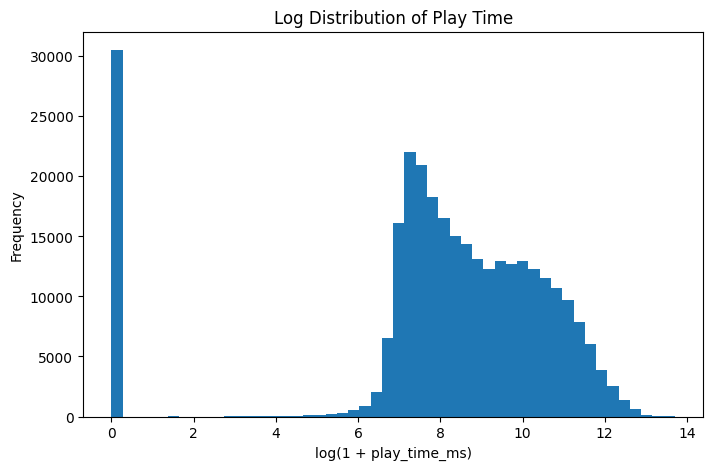

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(np.log1p(log_standard["play_time_ms"]), bins=50)
plt.title("Log Distribution of Play Time")
plt.xlabel("log(1 + play_time_ms)")
plt.ylabel("Frequency")
plt.show()

In [12]:
user_interaction_counts = log_standard.groupby("user_id").size()

user_interaction_counts.describe()


count    25877.000000
mean        11.419291
std         10.895080
min          1.000000
25%          4.000000
50%          8.000000
75%         15.000000
max        160.000000
dtype: float64

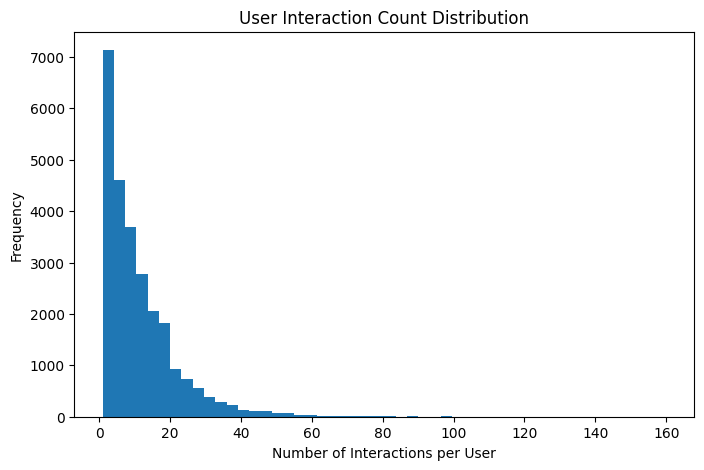

In [13]:
plt.figure(figsize=(8,5))
plt.hist(user_interaction_counts, bins=50)
plt.title("User Interaction Count Distribution")
plt.xlabel("Number of Interactions per User")
plt.ylabel("Frequency")
plt.show()

In [14]:
cold_users = (user_interaction_counts == 1).sum()
cold_users / len(user_interaction_counts)

0.06693202457781042

In [15]:
video_interaction_counts = log_standard.groupby("video_id").size()

video_interaction_counts.describe()

count    6618.000000
mean       44.650499
std       100.324744
min         1.000000
25%         4.000000
50%        12.000000
75%        40.000000
max      1886.000000
dtype: float64

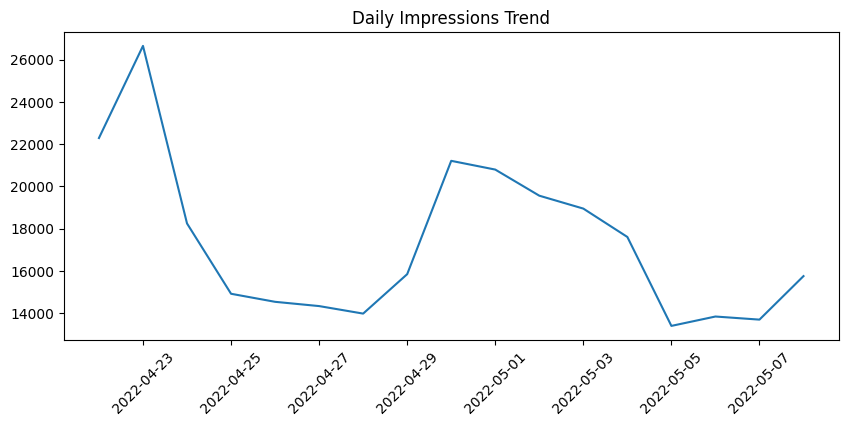

In [29]:
log_standard["date"] = pd.to_datetime(
    log_standard["date"]
)

daily_show = (
    log_standard
    .groupby("date")
    .size()
    .reset_index(name="impressions")
)

plt.figure(figsize=(10,4))
plt.plot(daily_show["date"], daily_show["impressions"])
plt.title("Daily Impressions Trend")
plt.xticks(rotation=45)
plt.show()

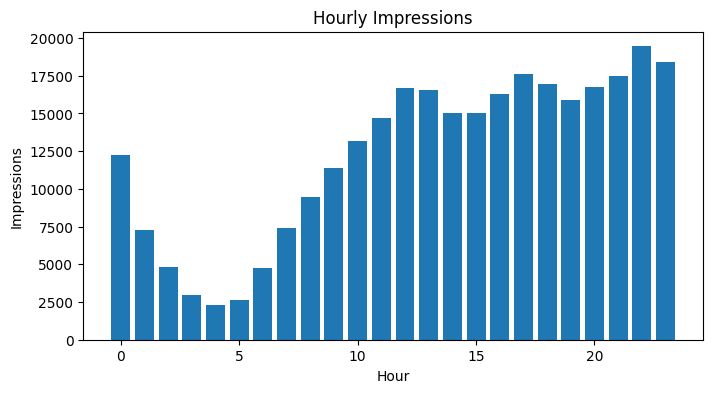

In [32]:
log_standard["hour"] = log_standard["hourmin"] // 100

hourly_show = (
    log_standard
    .groupby("hour")
    .size()
    .reset_index(name="impressions")
)

plt.figure(figsize=(8,4))
plt.bar(hourly_show["hour"], hourly_show["impressions"])
plt.title("Hourly Impressions")
plt.xlabel("Hour")
plt.ylabel("Impressions")
plt.show()


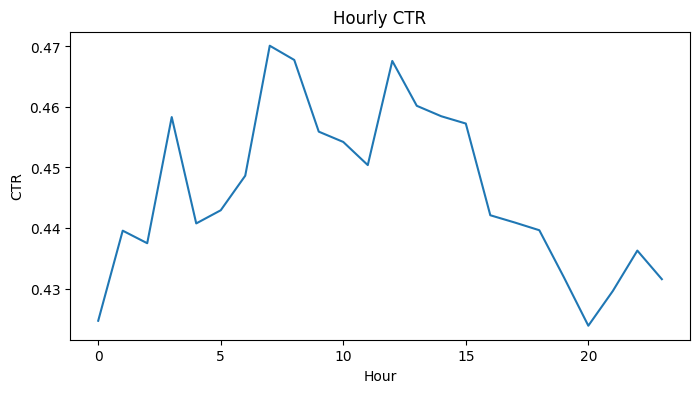

In [33]:
hourly_ctr = (
    log_standard
    .groupby("hour")["is_click"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(hourly_ctr["hour"], hourly_ctr["is_click"])
plt.title("Hourly CTR")
plt.xlabel("Hour")
plt.ylabel("CTR")
plt.show()

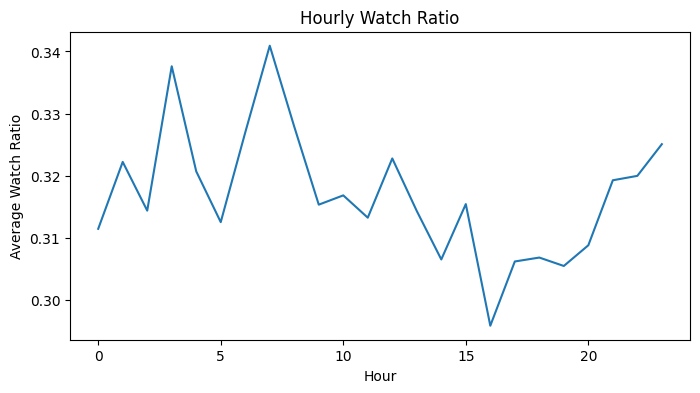

In [39]:
log_standard["watch_ratio"] = (
    log_standard["play_time_ms"] /
    log_standard["duration_ms"]
).clip(upper=1)

hourly_watch = (
    log_standard
    .groupby("hour")["watch_ratio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(hourly_watch["hour"], hourly_watch["watch_ratio"])
plt.title("Hourly Watch Ratio")
plt.xlabel("Hour")
plt.ylabel("Average Watch Ratio")
plt.show()

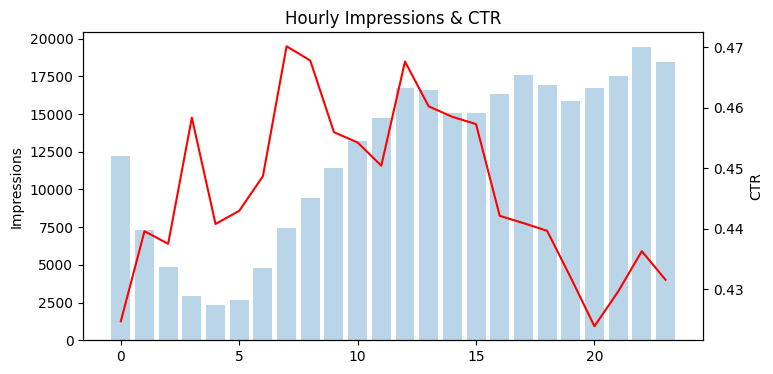

In [35]:
fig, ax1 = plt.subplots(figsize=(8,4))

ax1.bar(hourly_show["hour"], hourly_show["impressions"], alpha=0.3)
ax1.set_ylabel("Impressions")

ax2 = ax1.twinx()
ax2.plot(hourly_ctr["hour"], hourly_ctr["is_click"], color="red")
ax2.set_ylabel("CTR")

plt.title("Hourly Impressions & CTR")
plt.show()

In [40]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: C:\Users\86136\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


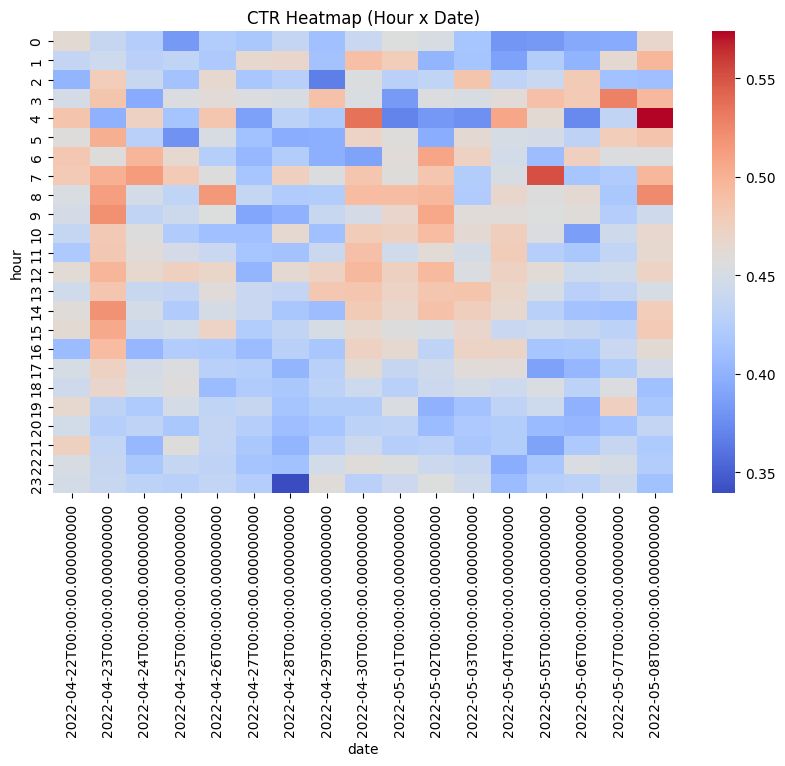

In [41]:
pivot = log_standard.pivot_table(
    index="hour",
    columns="date",
    values="is_click",
    aggfunc="mean"
)

import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("CTR Heatmap (Hour x Date)")
plt.show()

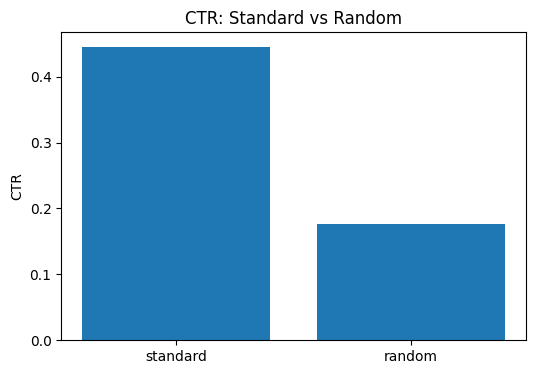

In [42]:
ctr_compare = pd.DataFrame({
    "type": ["standard", "random"],
    "ctr": [
        log_standard["is_click"].mean(),
        log_random["is_click"].mean()
    ]
})

plt.figure(figsize=(6,4))
plt.bar(ctr_compare["type"], ctr_compare["ctr"])
plt.title("CTR: Standard vs Random")
plt.ylabel("CTR")
plt.show()

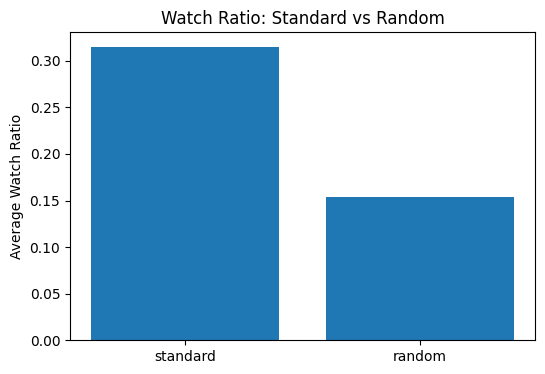

In [43]:
log_random["watch_ratio"] = (
    log_random["play_time_ms"] /
    log_random["duration_ms"]
).clip(upper=1)

watch_compare = pd.DataFrame({
    "type": ["standard", "random"],
    "watch_ratio": [
        log_standard["watch_ratio"].mean(),
        log_random["watch_ratio"].mean()
    ]
})

plt.figure(figsize=(6,4))
plt.bar(watch_compare["type"], watch_compare["watch_ratio"])
plt.title("Watch Ratio: Standard vs Random")
plt.ylabel("Average Watch Ratio")
plt.show()

C:\Users\86136\AppData\Local\Temp\ipykernel_3100\609910629.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("show_bucket")["play_cnt"]
C:\Users\86136\AppData\Local\Temp\ipykernel_3100\609910629.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  video_stat.groupby("show_bucket")["show_cnt"].sum()


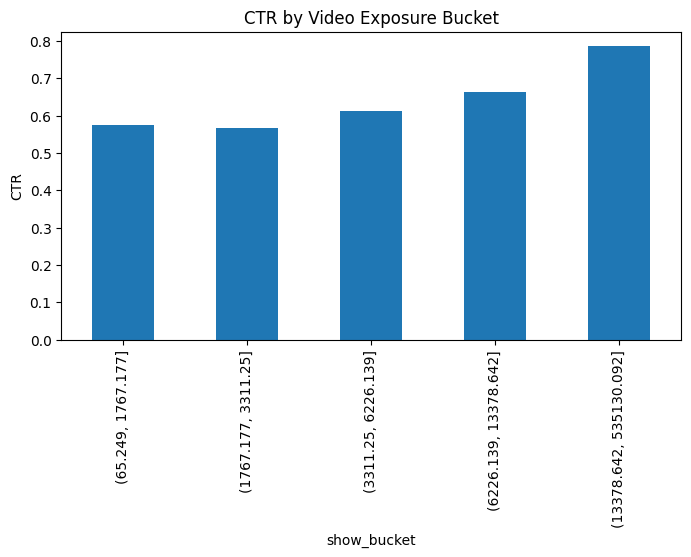

In [44]:
video_bucket = pd.qcut(video_stat["show_cnt"], 5)

video_stat["show_bucket"] = video_bucket

bucket_ctr = (
    video_stat
    .groupby("show_bucket")["play_cnt"]
    .sum()
    /
    video_stat.groupby("show_bucket")["show_cnt"].sum()
)

bucket_ctr.plot(kind="bar", figsize=(8,4))
plt.title("CTR by Video Exposure Bucket")
plt.ylabel("CTR")
plt.show()

C:\Users\86136\AppData\Local\Temp\ipykernel_3100\521009144.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("user_bucket")["is_click"]


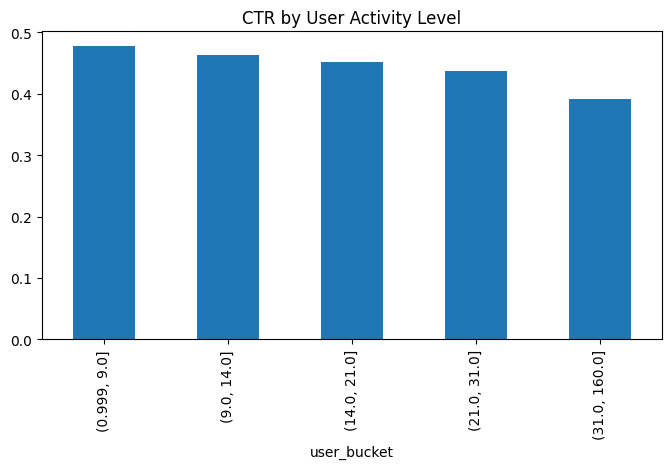

In [45]:
user_exposure = (
    log_standard
    .groupby("user_id")
    .size()
)

log_standard["user_bucket"] = pd.qcut(
    log_standard["user_id"].map(user_exposure),
    5
)

user_bucket_ctr = (
    log_standard
    .groupby("user_bucket")["is_click"]
    .mean()
)

user_bucket_ctr.plot(kind="bar", figsize=(8,4))
plt.title("CTR by User Activity Level")
plt.show()

C:\Users\86136\AppData\Local\Temp\ipykernel_3100\521009144.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("user_bucket")["is_click"]


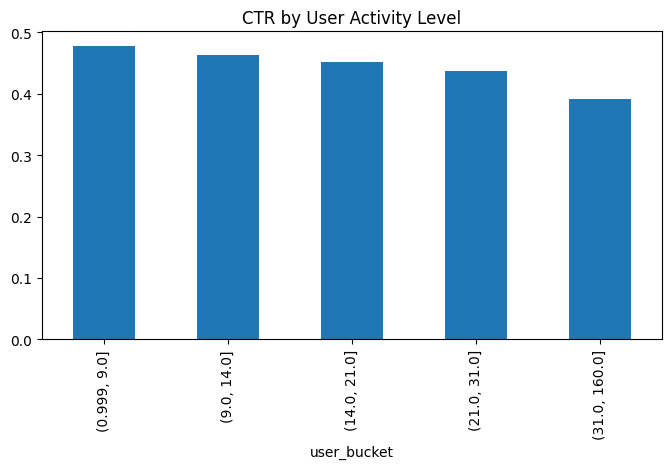

In [48]:
user_exposure = (
    log_standard
    .groupby("user_id")
    .size()
)

log_standard["user_bucket"] = pd.qcut(
    log_standard["user_id"].map(user_exposure),
    5
)

user_bucket_ctr = (
    log_standard
    .groupby("user_bucket")["is_click"]
    .mean()
)

user_bucket_ctr.plot(kind="bar", figsize=(8,4))
plt.title("CTR by User Activity Level")
plt.show()

C:\Users\86136\AppData\Local\Temp\ipykernel_3100\1957933948.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("duration_bucket")["watch_ratio"]


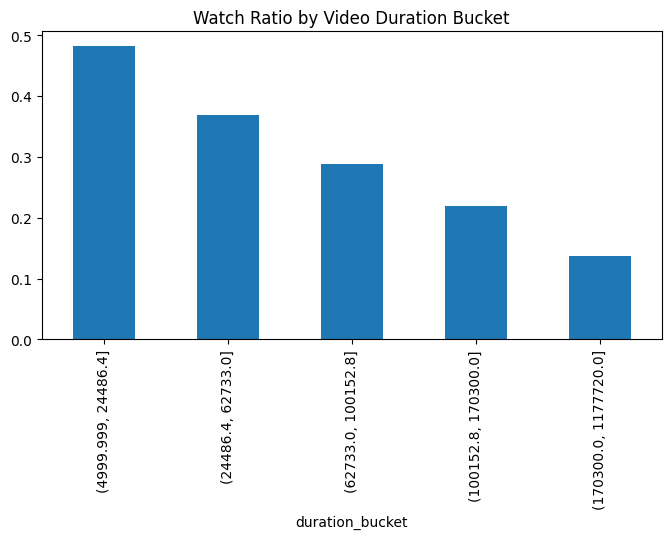

In [47]:
video_basic["duration_bucket"] = pd.qcut(
    video_basic["video_duration"], 5
)

merged = log_standard.merge(
    video_basic[["video_id", "duration_bucket"]],
    on="video_id"
)

duration_watch = (
    merged
    .groupby("duration_bucket")["watch_ratio"]
    .mean()
)

duration_watch.plot(kind="bar", figsize=(8,4))
plt.title("Watch Ratio by Video Duration Bucket")
plt.show()